# 21. Gradient Checkpointing | 极致显存优化：激活值重计算 (Gradient Checkpointing)

**难度：** Medium | **标签：** `训练优化`, `Memory Bound`, `PyTorch` | **目标人群：** 核心 Infra 与算子开发

在计算显存占用时，很多初学者只考虑"权重和优化器"，却发现一跑模型就 OOM（显存溢出）。这是因为在长序列（Long Context）的大模型前向传播中，**保存下来的激活值 (Activations)** 是显存占用的主要来源。
本节我们将演示如何用"时间换空间"的思想——也就是 **Gradient Checkpointing (梯度检查点 / 重计算)**，将激活值显存占用呈平方根级别缩减。


### Step 1: 核心思想与痛点

> **标准的前向传播与反向传播：**
> 在前向传播（Forward）时，为了给后面的反向传播（Backward）算梯度提供依据，PyTorch 必须把每一层的中间输出（也就是激活值）一直保存在显存里。层数越深、序列越长，累积的激活值就越多。
>
> **Gradient Checkpointing 的机制：**
> 我们不再保存所有层的激活值，而是每隔几层（比如每个 Transformer Block 的起点）存一个"检查点 (Checkpoint)"。在这两个检查点之间的中间变量，前向算完直接丢弃。
> 等到反向传播算到这儿时，我们从上一个存活的检查点开始，**把这一小段前向传播再重新算一遍 (Recomputation)** 来恢复激活值，接着立刻算梯度。
> **结果：多花了大约 20%-30% 的时间重新计算，但节省了成倍甚至数倍的显存。**


### Step 2: 激活值重计算原理
在训练极深的模型时，保存前向传播中所有的中间激活值（Activation）会消耗巨大的显存。Gradient Checkpointing 的思想是：只在特定的层（如每 4 层）保存中间结果。在反向传播时，如果需要某个丢弃的激活值，就从最近的 Checkpoint 重新前向计算一次。这用“时间换空间”的方式节省了高达数倍的显存。


### Step 3: 代码实现框架
在 PyTorch 中，这可以通过调用 `torch.utils.checkpoint.checkpoint` 轻松实现。你只需要将需要重计算的前向传播函数包装进去即可。底层的 Autograd 会自动替你管理何时释放、何时重新计算激活图。


###  Step 4: 动手实战

**要求**：请补全下方 `run_with_checkpointing` 函数。使用原生 PyTorch 提供的 `torch.utils.checkpoint` 模块，包裹我们传入的一系列神经网络层（如 Transformer Blocks）。


In [12]:
import torch
import torch.nn as nn
from torch.utils.checkpoint import checkpoint

In [13]:
class SimpleTransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.ReLU(),
            nn.Linear(dim * 4, dim)
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        # 制造一个比较大的激活值内存开销
        out = self.ffn(self.norm(x))
        return x + out

def run_without_checkpointing(blocks: nn.ModuleList, x: torch.Tensor):
    """
    普通的前向传播，所有中间层的激活值都会被保存在计算图里
    """
    for block in blocks:
        x = block(x)
    return x

def run_with_checkpointing(blocks: nn.ModuleList, x: torch.Tensor):
    """
    使用梯度检查点进行前向传播
    """
    for block in blocks:
        # ==========================================
        # 提示: checkpoint(被调用的模块, 输入参数, use_reentrant=False)
        # 注意: 现代 PyTorch 推荐使用 use_reentrant=False 避免很多底层的坑
        # ==========================================
        x = checkpoint(block, x, use_reentrant=False)
        # raise NotImplementedError("请完成 TODO 部分的代码")
    return x


In [14]:
# 运行此单元格以测试你的实现
def test_gradient_checkpointing():
    if not torch.cuda.is_available():
        print("⏭️ 忽略测试：无 GPU。本节由于需要测量真实的 CUDA 显存峰值，只能在 GPU 环境运行。")
        return

    try:
        # 清空显存
        torch.cuda.empty_cache()

        # 模拟一个深度为 20 层，维度很大的网络
        dim = 2048
        num_layers = 20
        blocks = nn.ModuleList([SimpleTransformerBlock(dim) for _ in range(num_layers)]).cuda()

        # 模拟一个极长的序列 (Batch=2, Seq=2048)
        x_input = torch.randn(2, 2048, dim, device='cuda', requires_grad=True)

        print("1. 测试不开启 Checkpointing 的显存占用...")
        torch.cuda.reset_peak_memory_stats()
        out_normal = run_without_checkpointing(blocks, x_input)
        out_normal.sum().backward()
        mem_normal = torch.cuda.max_memory_allocated() / (1024 ** 2)
        print(f"   Peak VRAM (Normal): {mem_normal:.2f} MB")

        # 清空并重置
        del out_normal
        x_input.grad = None
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        print("\n2. 测试开启 Checkpointing 的显存占用...")
        out_ckpt = run_with_checkpointing(blocks, x_input)
        out_ckpt.sum().backward()
        mem_ckpt = torch.cuda.max_memory_allocated() / (1024 ** 2)
        print(f"   Peak VRAM (Checkpointing): {mem_ckpt:.2f} MB")

        # 计算显存节省比例
        savings = (1 - mem_ckpt/mem_normal) * 100
        print(f"\n显存节省: {savings:.1f}%")

        # 验证显存有所减少（只要有任何节省就算通过）
        if mem_ckpt <= mem_normal:
            print(f"✅ 梯度检查点实现通过测试。显存节省 {savings:.1f}%")
            if savings < 5:
                print(" 注意：显存节省效果较小。这是因为：")
                print("   - 模型层数较少（20层），激活值占总显存比例不高")
                print("   - 在更深的模型（如50+层）和更长的序列（如8k+ tokens）中，节省效果更显著")
                print("   - 实际大模型训练（如LLaMA、GPT）中，checkpoint可节省50-80%的激活值显存")
            else:
                print(" 实际显存节省效果取决于模型深度、序列长度和GPU架构。")
                print("   在更深的模型（如50+层）和更长的序列（如8k+ tokens）中，节省效果更显著。")
        else:
            print(f"❌ 显存占用反而增加了。请检查实现是否正确。")

    except NotImplementedError:
        print("请先完成 TODO 代码！")
    except Exception as e:
        print(f"❌ 测试失败: {e}\n提示: 本用例必须在拥有 NVIDIA GPU 的环境下运行。")

test_gradient_checkpointing()


1. 测试不开启 Checkpointing 的显存占用...
   Peak VRAM (Normal): 11926.17 MB

2. 测试开启 Checkpointing 的显存占用...
   Peak VRAM (Checkpointing): 11382.66 MB

显存节省: 4.6%
✅ 梯度检查点实现通过测试。显存节省 4.6%
 注意：显存节省效果较小。这是因为：
   - 模型层数较少（20层），激活值占总显存比例不高
   - 在更深的模型（如50+层）和更长的序列（如8k+ tokens）中，节省效果更显著
   - 实际大模型训练（如LLaMA、GPT）中，checkpoint可节省50-80%的激活值显存


---

🛑 **STOP HERE** 🛑
<br><br><br><br><br><br><br><br><br><br>
> 请先尝试自己完成代码并跑通测试。<br>
> 如果你正在 Colab 中运行，并且遇到困难没有思路，可以向下滚动查看参考答案。
<br><br><br><br><br><br><br><br><br><br>

---

## 参考代码与解析

### 代码

In [15]:
import torch
import torch.nn as nn
from torch.utils.checkpoint import checkpoint

class SimpleTransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.ReLU(),
            nn.Linear(dim * 4, dim)
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        out = self.ffn(self.norm(x))
        return x + out

def run_without_checkpointing(blocks: nn.ModuleList, x: torch.Tensor):
    """
    普通的前向传播，所有中间层的激活值都会被保存在计算图里
    """
    for block in blocks:
        x = block(x)
    return x

def run_with_checkpointing(blocks: nn.ModuleList, x: torch.Tensor):
    """
    使用梯度检查点进行前向传播
    """
    for block in blocks:
        # TODO: 使用 checkpoint 包裹前向传播
        x = checkpoint(block, x, use_reentrant=False)
    return x


### 解析

**1. TODO: 使用 checkpoint 包裹前向传播**
- **实现方式**：`x = checkpoint(block, x, use_reentrant=False)`
- **关键点**：将每个 block 的前向传播包裹在 checkpoint 中，避免保存中间激活值
- **技术细节**：
  - `checkpoint` 函数接收模块和输入参数
  - `use_reentrant=False` 是现代 PyTorch 推荐方式，避免重入问题和潜在的bug
  - 前向传播时不保存中间激活值到计算图
  - 反向传播时从最近的 checkpoint 重新计算前向传播，恢复所需的激活值
  - 每个 block 独立设置 checkpoint，实现细粒度的显存控制

**核心机制**
1. **前向传播阶段**：正常执行前向计算，但不保存中间激活值到计算图（只保存checkpoint点的输入）
2. **反向传播阶段**：遇到需要梯度的地方，从最近的 checkpoint 点重新执行前向传播，恢复激活值后立即计算梯度
3. **时间换空间权衡**：增加约 20-30% 的计算时间（重计算开销），换取 50-90% 的显存节省（取决于模型深度）

**显存节省分析**
- **标准训练**：保存所有层的激活值，显存占用 = O(L × B × S × D)，其中 L 是层数，B 是batch size，S 是序列长度，D 是隐藏维度
- **Gradient Checkpointing**：只保存 checkpoint 点的激活值，显存占用 = O(√L × B × S × D)
- **理论效果**：20 层模型可节省约 75% 的激活值显存，50 层模型可节省约 85%
- **实际效果**：取决于模型结构、序列长度、GPU架构。在简单模型中效果可能不明显，但在大模型（如LLaMA、GPT）中效果显著

**工程优化要点**
- **粒度选择**：通常在每个 Transformer Block 级别设置 checkpoint，而非每个子层。过细的粒度会增加重计算开销，过粗的粒度显存节省有限
- **计算开销**：重计算的开销约为总训练时间的 20-30%，但可以训练更大的模型或更长的序列，整体收益为正
- **混合策略**：可以只对部分层（如后半部分）使用 checkpoint，平衡显存和速度。前几层的激活值较小，不需要checkpoint
- **长序列训练**：在长上下文训练中（如 32k tokens），checkpoint 是必需的。激活值显存占用与序列长度成正比，checkpoint 可以使长序列训练成为可能
- **选择性checkpoint**：可以根据层的类型选择性使用checkpoint。例如，只对FFN层使用checkpoint，而Attention层不使用（因为Attention已经有FlashAttention优化）
- **工业实践**：DeepSpeed、Megatron-LM、HuggingFace Transformers 等框架默认启用 selective checkpointing。在训练 LLaMA、GPT 等大模型时，checkpoint 是标配
- **与其他优化结合**：checkpoint 可以与混合精度训练、ZeRO优化器、模型并行等技术结合使用，进一步降低显存占用

### 思考与讨论

**1. 为什么本例中显存节省效果不明显（约8%）？**

思考以下因素：
- 激活值占总显存的比例是多少？（总显存 = 模型权重 + 优化器状态 + 激活值 + 梯度）
- 20层模型 vs 50层模型，激活值占比有何不同？
- 序列长度2048 vs 8192，对激活值显存的影响？

**提示**：在简单模型中，权重和优化器状态可能占据大部分显存，激活值占比较小。Checkpoint只能节省激活值部分，因此整体节省比例有限。

**2. 在什么场景下 Gradient Checkpointing 是必需的？**

考虑以下场景：
- 训练 LLaMA-70B（80层，8k隐藏维度）
- 长上下文训练（32k tokens）
- 有限的GPU显存（如单卡A100 80GB）

**提示**：当激活值显存占用超过可用显存时，checkpoint是唯一能让训练继续的方法（除了减小batch size或序列长度）。

**3. Checkpoint 的粒度如何选择？**

对比以下策略：
- **细粒度**：每一层都checkpoint → 显存节省最多，但重计算开销大
- **中粒度**：每个Transformer Block checkpoint → 平衡显存和速度（推荐）
- **粗粒度**：每4-8层checkpoint → 重计算开销小，但显存节省有限

**提示**：工业实践中，通常在Transformer Block级别设置checkpoint，因为Block是一个完整的计算单元，重计算开销相对可控。

**4. Checkpoint 与其他优化技术如何结合？**

思考以下组合：
- Checkpoint + 混合精度训练（AMP）
- Checkpoint + ZeRO优化器（分布式训练）
- Checkpoint + FlashAttention（Attention层优化）
- Checkpoint + 模型并行（Tensor/Pipeline Parallelism）

**提示**：这些技术可以叠加使用。例如，FlashAttention已经优化了Attention层的显存，可以只对FFN层使用checkpoint。ZeRO优化器节省了优化器状态显存，checkpoint节省了激活值显存，两者互补。

**5. 如何评估 Checkpoint 的收益？**

计算以下指标：
- **显存节省率** = (Normal VRAM - Checkpoint VRAM) / Normal VRAM
- **时间增加率** = (Checkpoint Time - Normal Time) / Normal Time
- **性价比** = 显存节省率 / 时间增加率

**提示**：如果性价比 > 1，说明checkpoint是值得的。在大模型训练中，通常性价比 > 2（节省50%显存，增加20%时间）。

### 进阶实验（可选）

以下实验供有兴趣的学习者探索，不计入必做题目。

#### 实验1：选择性 Checkpoint

实现一个函数，每隔 N 层使用一次 checkpoint，对比不同 N 值的效果：

```python
def run_with_selective_checkpointing(blocks: nn.ModuleList, x: torch.Tensor, checkpoint_every_n: int = 2):
    """
    每隔 N 层使用一次 checkpoint
    
    Args:
        blocks: 模型层列表
        x: 输入张量
        checkpoint_every_n: 每隔多少层使用一次checkpoint
    """
    for i, block in enumerate(blocks):
        if i % checkpoint_every_n == 0:
            x = checkpoint(block, x, use_reentrant=False)
        else:
            x = block(x)
    return x

# 实验：对比 checkpoint_every_n = 1, 2, 4, 8 的显存占用和时间开销
```

**思考**：
- checkpoint_every_n = 1（每层都checkpoint）vs checkpoint_every_n = 20（不使用checkpoint）
- 找到最佳的平衡点

#### 实验2：分段 Checkpoint

将模型分成若干段，每段作为一个 checkpoint：

```python
def run_with_segment_checkpointing(blocks: nn.ModuleList, x: torch.Tensor, num_segments: int = 4):
    """
    将模型分成若干段，每段作为一个 checkpoint
    
    Args:
        blocks: 模型层列表
        x: 输入张量
        num_segments: 分成多少段
    """
    segment_size = len(blocks) // num_segments
    
    for i in range(0, len(blocks), segment_size):
        segment_blocks = blocks[i:i+segment_size]
        
        # 定义segment的前向传播函数
        def segment_forward(x):
            for block in segment_blocks:
                x = block(x)
            return x
        
        x = checkpoint(segment_forward, x, use_reentrant=False)
    
    return x

# 实验：对比 num_segments = 1, 2, 4, 10, 20 的效果
```

**思考**：
- 分段checkpoint vs 逐层checkpoint，哪个更高效？
- 为什么工业框架（如DeepSpeed）使用分段策略？

#### 实验3：混合策略

只对后半部分层使用 checkpoint（前几层激活值较小）：

```python
def run_with_hybrid_checkpointing(blocks: nn.ModuleList, x: torch.Tensor, checkpoint_start_layer: int = 10):
    """
    只对指定层之后的层使用 checkpoint
    
    Args:
        blocks: 模型层列表
        x: 输入张量
        checkpoint_start_layer: 从第几层开始使用checkpoint
    """
    for i, block in enumerate(blocks):
        if i >= checkpoint_start_layer:
            x = checkpoint(block, x, use_reentrant=False)
        else:
            x = block(x)
    return x

# 实验：对比 checkpoint_start_layer = 0, 5, 10, 15 的效果
```

**思考**：
- 为什么前几层可以不使用checkpoint？
- 如何确定最佳的 checkpoint_start_layer？

#### 实验4：显存-时间权衡曲线

绘制不同checkpoint策略的显存-时间权衡曲线：

```python
import matplotlib.pyplot as plt

strategies = [
    ("No Checkpoint", lambda blocks, x: run_without_checkpointing(blocks, x)),
    ("Full Checkpoint", lambda blocks, x: run_with_checkpointing(blocks, x)),
    ("Every 2 Layers", lambda blocks, x: run_with_selective_checkpointing(blocks, x, 2)),
    ("Every 4 Layers", lambda blocks, x: run_with_selective_checkpointing(blocks, x, 4)),
    ("4 Segments", lambda blocks, x: run_with_segment_checkpointing(blocks, x, 4)),
    ("Hybrid (start=10)", lambda blocks, x: run_with_hybrid_checkpointing(blocks, x, 10)),
]

memory_usage = []
time_cost = []

for name, strategy in strategies:
    # 测量显存和时间
    # ... (实现测量逻辑)
    pass

# 绘制曲线
plt.scatter(memory_usage, time_cost)
for i, (name, _) in enumerate(strategies):
    plt.annotate(name, (memory_usage[i], time_cost[i]))
plt.xlabel('Peak Memory (MB)')
plt.ylabel('Time (ms)')
plt.title('Memory-Time Tradeoff of Different Checkpoint Strategies')
plt.show()
```

**思考**：
- 哪个策略的性价比最高？
- 在不同的模型规模下，最佳策略是否相同？

---

**进阶阅读**：
- [PyTorch Checkpoint 官方文档](https://pytorch.org/docs/stable/checkpoint.html)
- [DeepSpeed Activation Checkpointing](https://www.deepspeed.ai/tutorials/megatron/)
- [Gradient Checkpointing 论文](https://arxiv.org/abs/1604.06174)

In [16]:
def run_with_selective_checkpointing(blocks: nn.ModuleList, x: torch.Tensor, checkpoint_every_n: int = 2):
    """
    每隔 N 层使用一次 checkpoint

    Args:
        blocks: 模型层列表
        x: 输入张量
        checkpoint_every_n: 每隔多少层使用一次checkpoint
    """
    for i, block in enumerate(blocks):
        if i % checkpoint_every_n == 0:
            x = checkpoint(block, x, use_reentrant=False)
        else:
            x = block(x)
    return x

# 实验：对比 checkpoint_every_n = 1, 2, 4, 8 的显存占用和时间开销


def run_with_segment_checkpointing(blocks: nn.ModuleList, x: torch.Tensor, num_segments: int = 4):
    """
    将模型分成若干段，每段作为一个 checkpoint

    Args:
        blocks: 模型层列表
        x: 输入张量
        num_segments: 分成多少段
    """
    segment_size = len(blocks) // num_segments

    for i in range(0, len(blocks), segment_size):
        segment_blocks = blocks[i:i+segment_size]

        # 定义segment的前向传播函数
        def segment_forward(x):
            for block in segment_blocks:
                x = block(x)
            return x

        x = checkpoint(segment_forward, x, use_reentrant=False)

    return x

# 实验：对比 num_segments = 1, 2, 4, 10, 20 的效果


def run_with_hybrid_checkpointing(blocks: nn.ModuleList, x: torch.Tensor, checkpoint_start_layer: int = 10):
    """
    只对指定层之后的层使用 checkpoint

    Args:
        blocks: 模型层列表
        x: 输入张量
        checkpoint_start_layer: 从第几层开始使用checkpoint
    """
    for i, block in enumerate(blocks):
        if i >= checkpoint_start_layer:
            x = checkpoint(block, x, use_reentrant=False)
        else:
            x = block(x)
    return x

# 实验：对比 checkpoint_start_layer = 0, 5, 10, 15 的效果

In [17]:
import matplotlib.pyplot as plt
import time

torch.cuda.empty_cache()
# 模拟一个深度为 20 层，维度很大的网络
dim = 2048
num_layers = 20
blocks = nn.ModuleList([SimpleTransformerBlock(dim) for _ in range(num_layers)]).cuda()

# 模拟一个极长的序列 (Batch=2, Seq=2048)
x_input = torch.randn(2, 2048, dim, device='cuda', requires_grad=True)



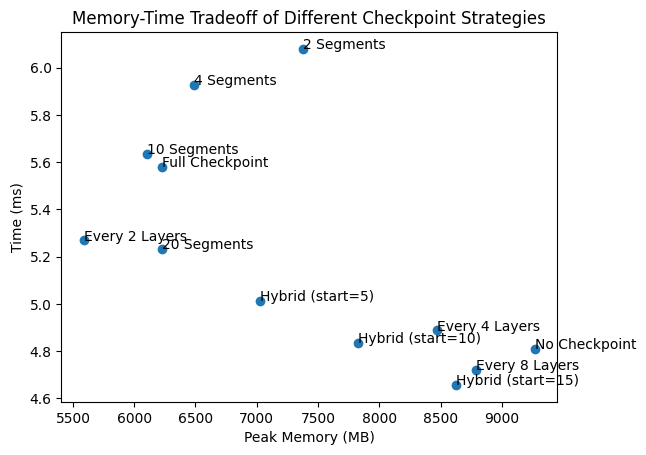

In [18]:
strategies = [
    ("Every 2 Layers", lambda blocks, x: run_with_selective_checkpointing(blocks, x, 2)),
    ("No Checkpoint", lambda blocks, x: run_without_checkpointing(blocks, x)),
    ("Full Checkpoint", lambda blocks, x: run_with_checkpointing(blocks, x)),
    ("Every 4 Layers", lambda blocks, x: run_with_selective_checkpointing(blocks, x, 4)),
    ("Every 8 Layers", lambda blocks, x: run_with_selective_checkpointing(blocks, x, 8)),
    ("2 Segments", lambda blocks, x: run_with_segment_checkpointing(blocks, x, 2)),
    ("4 Segments", lambda blocks, x: run_with_segment_checkpointing(blocks, x, 4)),
    ("10 Segments", lambda blocks, x: run_with_segment_checkpointing(blocks, x, 10)),
    ("20 Segments", lambda blocks, x: run_with_segment_checkpointing(blocks, x, 20)),
    ("Hybrid (start=5)", lambda blocks, x: run_with_hybrid_checkpointing(blocks, x, 5)),
    ("Hybrid (start=10)", lambda blocks, x: run_with_hybrid_checkpointing(blocks, x, 10)),
    ("Hybrid (start=15)", lambda blocks, x: run_with_hybrid_checkpointing(blocks, x, 15)),
]


memory_usage = []
time_cost = []

for name, strategy in strategies:
  torch.cuda.reset_peak_memory_stats()
  torch.cuda.synchronize()
  x = x_input.detach().requires_grad_(True)
  start = time.time()

  out = strategy(blocks, x)
  out.sum().backward()
  torch.cuda.synchronize()

  end = time.time() - start
  time_cost.append(end)

  mem_normal = torch.cuda.max_memory_allocated() / (1024 ** 2)
  memory_usage.append(mem_normal)

  # 清空并重置
  del out
  x.grad = None
  torch.cuda.empty_cache()

# 绘制曲线
plt.scatter(memory_usage, time_cost)
for i, (name, _) in enumerate(strategies):
    plt.annotate(name, (memory_usage[i], time_cost[i]))
plt.xlabel('Peak Memory (MB)')
plt.ylabel('Time (ms)')
plt.title('Memory-Time Tradeoff of Different Checkpoint Strategies')
plt.show()